
# Subgraph in LangGraph

A **subgraph** is a graph used inside a **parent graph** as a node/workflow.

It helps break a complex workflow into smaller, modular workflows.

## Types of Subgraphs

### 1. Shared State Subgraph (Add a subgraph as a Node of parent graph)

The parent graph and subgraph **share the same state schema**.

```text
     Parent Graph
          ↓
     Subgraph
     ┌───────────┐
     │ Node A    │
     │    ↓      │
     │ Node B    │
     └───────────┘
          ↓
     Parent Graph
````

Useful when the subgraph needs to directly read/update the parent's state.

### 2. Different State Subgraph (Invoke subgraph from a Node)

The parent graph and subgraph have **different state schemas**.

The parent passes required data to the subgraph, and the subgraph returns its result.

```text
     Parent State
          ↓
     Input Mapping
          ↓
     Subgraph State
          ↓
     Subgraph Execution
          ↓
     Output Mapping
          ↓
     Parent State
```

Useful when you want the subgraph to be **independent and reusable**.

### Why use Subgraphs?

* Break complex workflows into smaller components.
* Improve modularity and maintainability.
* Reuse workflows.
* Separate responsibilities.
* Make complex agent workflows easier to manage.

> **Subgraph = a graph inside another graph.**



# Learning Project: Content Writer with Translation Subgraph

Build a **LangGraph content-writing workflow** where the user provides a topic and the system generates content for it.

The main graph should generate the content, then use a **translation subgraph** to translate the generated content into a language selected by the user.

User Input
→ Generate Content
→ Translation Subgraph
→ Translated Content
→ END

In [13]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from typing import TypedDict


In [14]:
llm = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite",
    temperature=0.6
)

# Child Graph

### SUBGRAPH: Translator


```python
State():
    content: str
    translation: str
```

In [15]:
class TranslatorState(TypedDict):
    content: str
    translation: str

In [19]:
def translator_node(state: TranslatorState):
    content = state["content"]
    prompt = PromptTemplate(
        template="""
Translate Below given content to English and only return the translation
content: {content}
""",
        input_variables=["content"],
        output_parser=StrOutputParser()
    )

    chain = prompt | llm

    resp = chain.invoke({"content": content})

    return {
        "translation": resp
    }

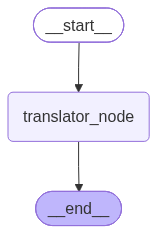

In [20]:
translatorGraph = StateGraph(TranslatorState)\
    .add_node("translator_node", translator_node)\
    .add_edge(START, "translator_node")\
    .add_edge("translator_node", END)\
    .compile()

translatorGraph

In [21]:
output = translatorGraph.invoke({'content': "mera naam bhavin hai"})
print(output)

{'content': 'mera naam bhavin hai', 'translation': AIMessage(content=[{'type': 'text', 'text': 'My name is Bhavin.', 'extras': {'signature': 'EnEKbwERTTIP/JnTv+4pVrUZ/IwZTEDyTWpKmWBgpJizTfQ52Na64HVQLlz8jiZLUlk+lDSiCR33L65OkPxBA7kc/9ccIipmk8temIN9sCCxBzteKzu9Gvsa2iPnPIKSN1RP6om+ymKt6uqEAfp2D6Zyng=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a019ac-6aba-7ff2-92ee-2d298c674f82-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 22, 'output_tokens': 6, 'total_tokens': 28, 'input_token_details': {'cache_read': 0}})}


# Parent Graph

### Content Generator



In [42]:
def content_generator(state):
    input_str = state["input_str"]

    prompt = PromptTemplate(
        template="""
You are a content writter expert.
write some 50 words of content for topic and return the content string
topic: {topic}
""",
        input_variables=["topic"],
        output_parser=StrOutputParser()
    )

    chain = prompt | llm

    resp = chain.invoke({"topic": input_str})

    return {
        "content": resp
    }



## Type 1:
#### Shared State Subgraph (Add a subgraph as a Node of parent graph)

In [48]:
class ShareState(TypedDict):
    input_str: str
    content: str
    translation: str

In [44]:
sharedStateContentGeneratorGraph = StateGraph(ShareState)\
    .add_node("content_generator", content_generator)\
    .add_node("translator_subgraph", translatorGraph)\
    .add_edge(START, "content_generator")\
    .add_edge("content_generator", "translator_subgraph")\
    .add_edge("translator_subgraph", END)\
    .compile()


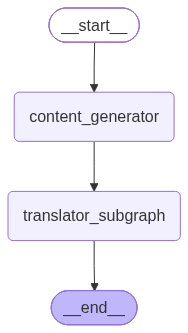

In [45]:
sharedStateContentGeneratorGraph

In [46]:
output = sharedStateContentGeneratorGraph.invoke({"input_str": "tajmahal ki sthapana"})

In [47]:
print(output["translation"].content[0]['text'])

The Taj Mahal was established by the Mughal Emperor Shah Jahan in memory of his beloved wife, Mumtaz Mahal. Its construction began in 1632 and was completed in approximately 22 years. This historical heritage site, made of white marble, is located in Agra and is considered one of the seven wonders of the world.


## Type 2:

#### Different State Subgraph (Invoke subgraph from a Node)


In [51]:
class NonSharableGraphState(TypedDict):
    input_str: str
    content: str
    translation: str

In [61]:
def translator_subgraph_invoker_node(state:NonSharableGraphState):
    initial_state = {
        "content": state["content"]
    }
    
    resp = translatorGraph.invoke(initial_state)
    return resp

In [62]:
nonSharableStateGraph = StateGraph(NonSharableGraphState)\
    .add_node("content_generator", content_generator)\
    .add_node("translator_subgraph_invoker_node", translator_subgraph_invoker_node)\
    .add_edge(START, "content_generator")\
    .add_edge("content_generator", "translator_subgraph_invoker_node")\
    .add_edge("translator_subgraph_invoker_node", END)\
    .compile()

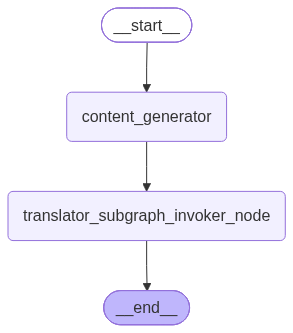

In [63]:
nonSharableStateGraph

In [64]:
output = nonSharableStateGraph.invoke({"input_str": "tajmahal ki sthapana"})

In [65]:
print(output["translation"].content[0]['text'])


The Taj Mahal was established by the Mughal Emperor Shah Jahan in memory of his beloved wife, Mumtaz Mahal. Its construction began in 1632 and was completed in approximately 22 years. This magnificent monument, built of white marble, is situated on the banks of the Yamuna River in Agra and is a symbol of love.
